# Personalized Treatment Outcome Prediction  
## Phase 1: Data Understanding & EDA

**Goal:** Understand the dataset to identify patterns and decide suitable models.


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [72]:
df=pd.read_csv("../data/raw/real_drug_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Condition,Drug_Name,Dosage_mg,Treatment_Duration_days,Side_Effects,Improvement_Score
0,P0001,56,Male,Infection,Ciprofloxacin,50,9,Nausea,8.5
1,P0002,69,Male,Hypertension,Metoprolol,500,24,Tiredness,8.7
2,P0003,46,Female,Depression,Bupropion,100,25,Dry mouth,5.4
3,P0004,32,Male,Diabetes,Glipizide,850,44,Low blood sugar,6.4
4,P0005,60,Male,Depression,Bupropion,850,35,Anxiety,5.3


---


In [73]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1000 non-null   object 
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   object 
 3   Condition                1000 non-null   object 
 4   Drug_Name                1000 non-null   object 
 5   Dosage_mg                1000 non-null   int64  
 6   Treatment_Duration_days  1000 non-null   int64  
 7   Side_Effects             1000 non-null   object 
 8   Improvement_Score        1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


### Dataset Overview
- Rows: 1000
- Columns: 9
- Target variable: Improvement_Score


---


In [74]:
df.isnull().sum()


Patient_ID                 0
Age                        0
Gender                     0
Condition                  0
Drug_Name                  0
Dosage_mg                  0
Treatment_Duration_days    0
Side_Effects               0
Improvement_Score          0
dtype: int64

In [75]:
df.duplicated().sum()

np.int64(0)

### Data Quality Observations
- Missing values present in: None
- Duplicate rows: 0





---


In [76]:
df['Age'].describe()

count    1000.000000
mean       49.857000
std        18.114267
min        18.000000
25%        35.000000
50%        50.000000
75%        66.000000
max        79.000000
Name: Age, dtype: float64

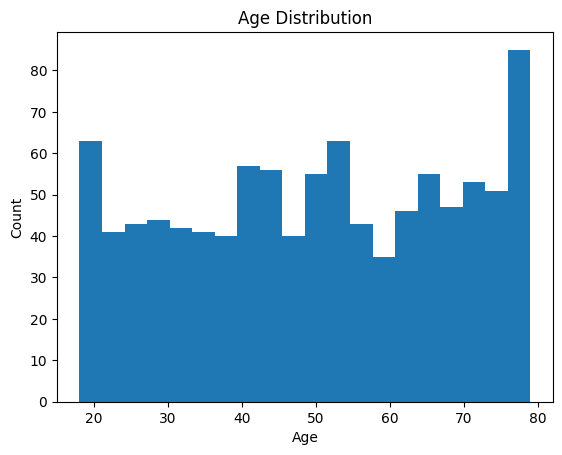

In [77]:
plt.hist(df['Age'],bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


### Age Distribution

This graph shows the distribution of patient ages in the dataset.

- The age of patients ranges from about 18 to 79 years.
- Patients belong to different age groups such as young, middle-aged, and elderly.
- There is no extreme concentration in any single age group.

**Conclusion:**  
The dataset contains patients from different age groups, which helps in studying how age affects treatment outcomes.



---


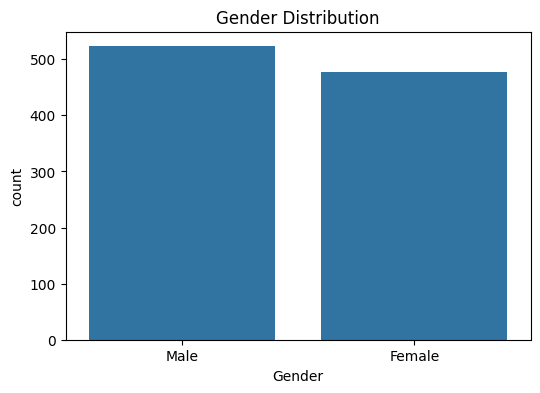

In [78]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

### Gender Distribution
- Visualizes the count of male vs female patients.
- The dataset appears to be relatively balanced between genders.

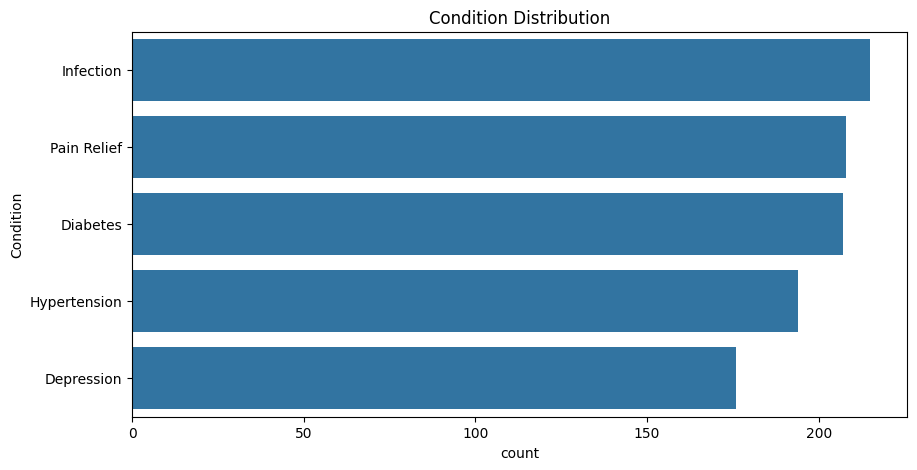

In [79]:
plt.figure(figsize=(10, 5))
sns.countplot(y='Condition', data=df, order=df['Condition'].value_counts().index)
plt.title("Condition Distribution")
plt.show()

### Condition Distribution
- Shows the frequency of different medical conditions treated in the dataset.

---


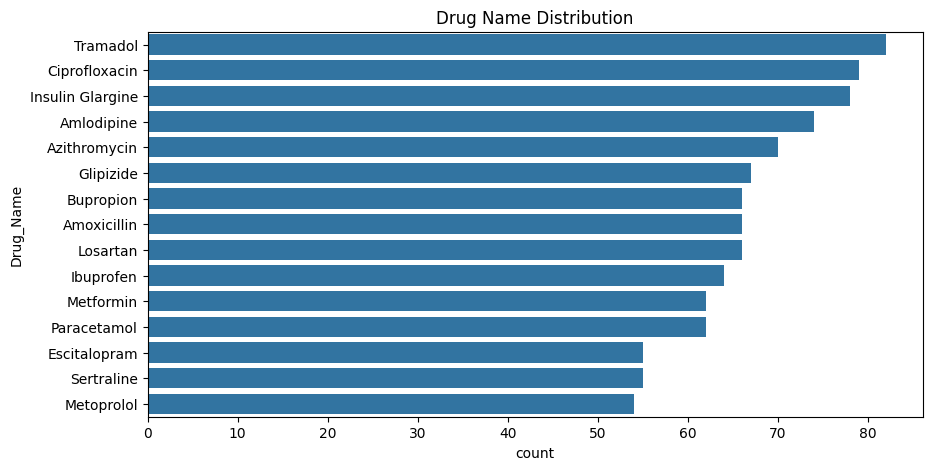

In [80]:
plt.figure(figsize=(10, 5))
sns.countplot(y='Drug_Name', data=df, order=df['Drug_Name'].value_counts().index)
plt.title("Drug Name Distribution")
plt.show()

### Drug Name Distribution
- Displays the most commonly prescribed drugs.

---


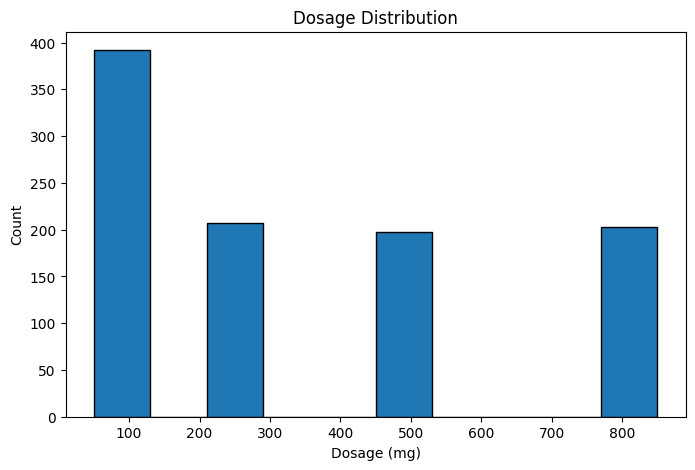

In [81]:
plt.figure(figsize=(8, 5))
plt.hist(df['Dosage_mg'], bins=10, edgecolor='black')
plt.xlabel("Dosage (mg)")
plt.ylabel("Count")
plt.title("Dosage Distribution")
plt.show()

### Dosage Distribution
- Shows the distribution of prescribed dosages.

---


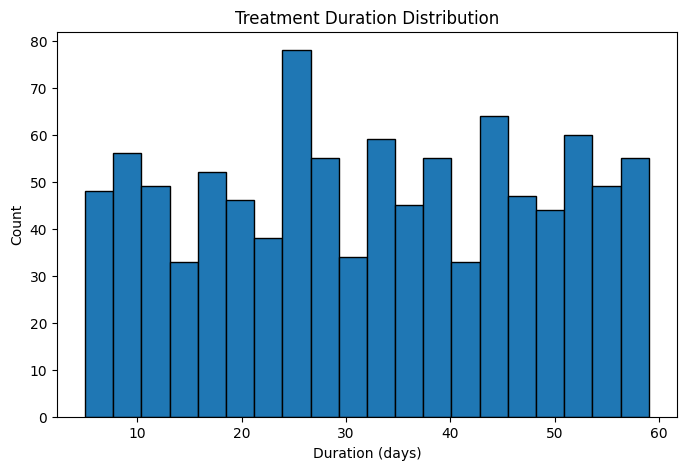

In [82]:
plt.figure(figsize=(8, 5))
plt.hist(df['Treatment_Duration_days'], bins=20, edgecolor='black')
plt.xlabel("Duration (days)")
plt.ylabel("Count")
plt.title("Treatment Duration Distribution")
plt.show()

### Treatment Duration Distribution
- Illustrates the range of treatment durations.

---


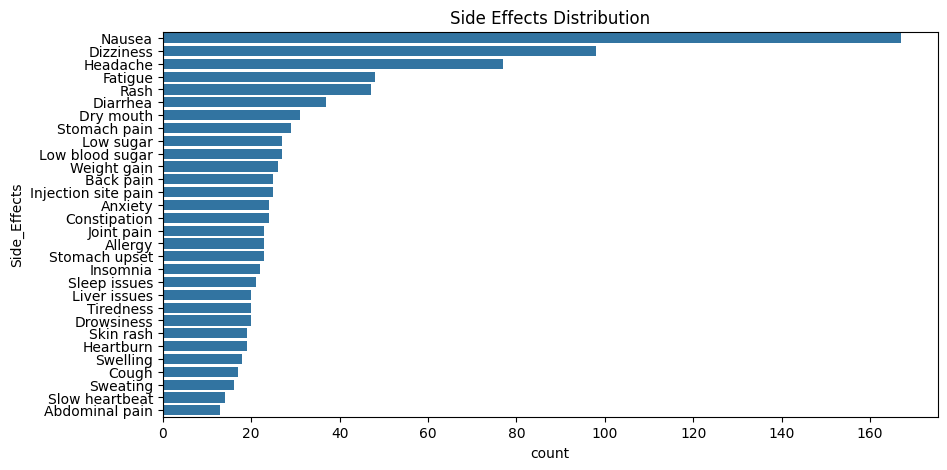

In [83]:
plt.figure(figsize=(10, 5))
sns.countplot(y='Side_Effects', data=df, order=df['Side_Effects'].value_counts().index)
plt.title("Side Effects Distribution")
plt.show()

### Side Effects Distribution
- Shows the frequency of reported side effects.

---


In [84]:
df['Improvement_Score'].describe()

count    1000.000000
mean        7.015200
std         1.425609
min         2.500000
25%         6.100000
50%         7.000000
75%         8.000000
max        10.000000
Name: Improvement_Score, dtype: float64

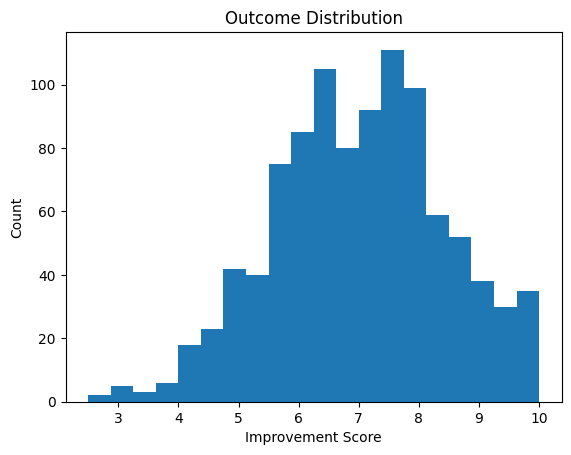

In [85]:
plt.hist(df['Improvement_Score'],bins=20)
plt.xlabel("Improvement Score")
plt.ylabel("Count")
plt.title("Outcome Distribution")
plt.show()


### Improvement Score Distribution

This graph shows how the improvement scores are distributed.

- Improvement scores range from 2.5 to 10.0
- Most patients have improvement scores between 6 and 8.
- The graph is slightly left skewed.

**Conclusion:**  
Treatment outcomes vary among patients, which means the model can learn meaningful patterns from the data.


### Univariate EDA Summary

- The age data is well spread across different age groups.
- Improvement scores show reasonable variation.
- There are no major issues like extreme imbalance or missing outcome values.
- **Age:** Well spread across different age groups.
- **Gender:** Balanced distribution.
- **Condition & Drugs:** Multiple conditions and drugs are represented.
- **Dosage & Duration:** Show varied distributions.
- **Side Effects:** Common side effects are identified.
- **Improvement Score:** Shows reasonable variation.

**Final Observation:**  
The dataset is suitable for further analysis and modeling.
 

---


# Bivariate Analysis and Feature Selection

**Goal:** Analyze relationships between variables and the target variable.

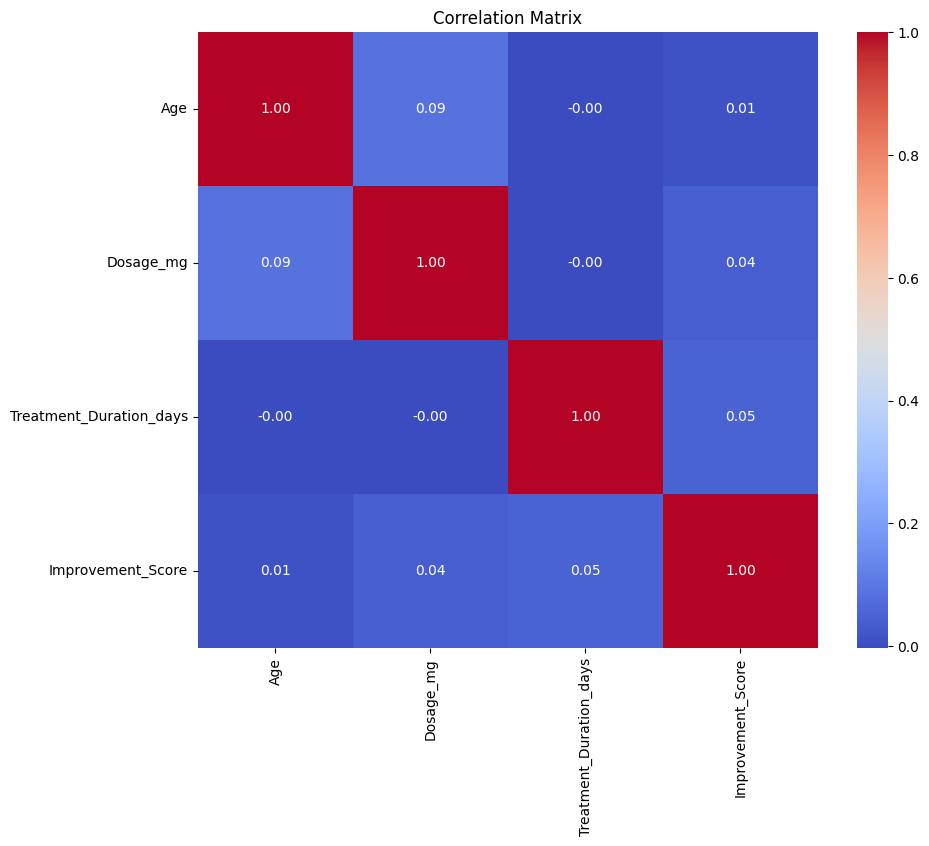

In [86]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix
- Shows linear relationships between numerical variables.
- Helps in identifying potential predictors for the model.

**Observations:**
- The correlation coefficients between numerical features and `Improvement_Score` are very close to zero.
- **Insight:** No strong linear relationships exist, suggesting that non-linear models (like Random Forest) might be more effective than simple linear regression.

---


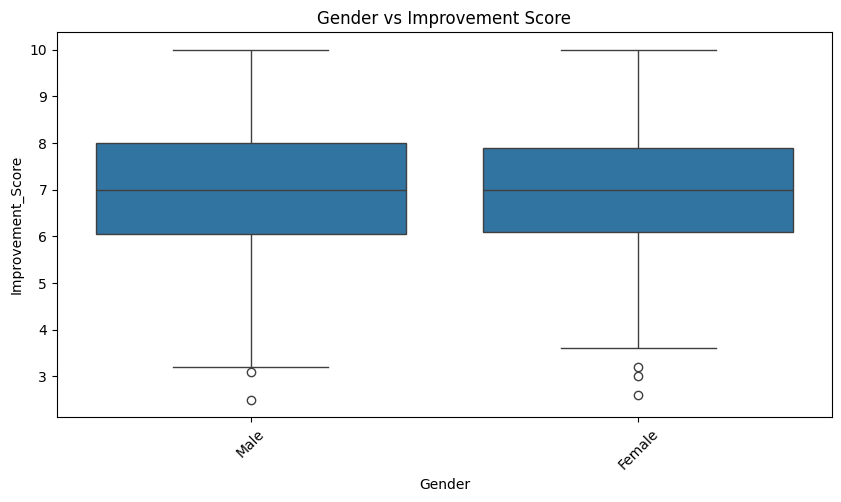

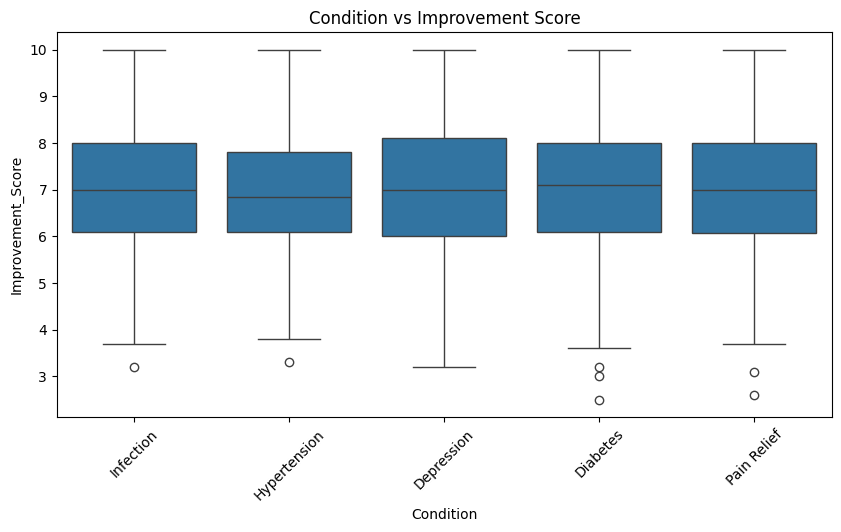

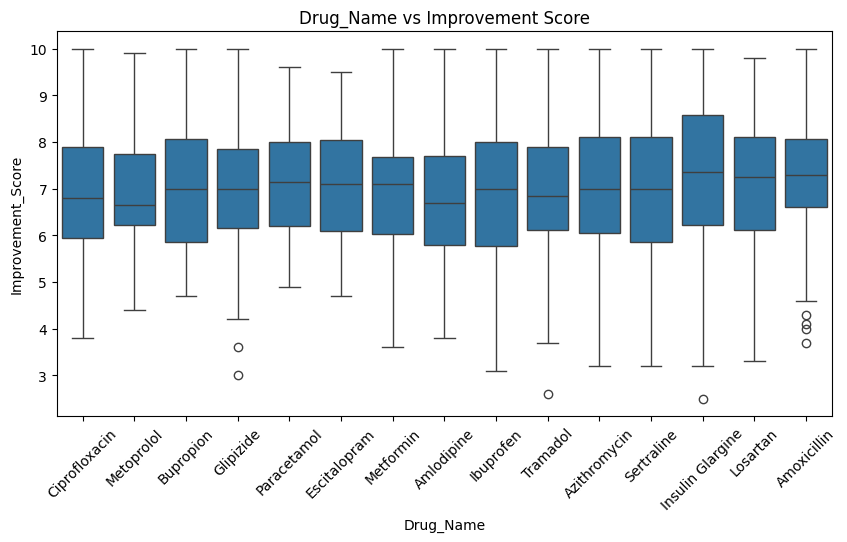

In [87]:
# Categorical variables vs Improvement Score
categorical_cols = ['Gender', 'Condition', 'Drug_Name']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='Improvement_Score', data=df)
    plt.title(f"{col} vs Improvement Score")
    plt.xticks(rotation=45)
    plt.show()

### Categorical vs Target
- Box plots reveal how the distribution of improvement scores differs across categories.
- We can see if certain drugs or conditions have higher median improvement scores.

**Observations:**
- **Gender:** No significant difference in outcomes between Male and Female patients.
- **Condition:** "Pain Relief" and "Hypertension" show higher median scores, while "Depression" has lower and more variable outcomes.
- **Drug Name:** Specific drugs like "Tramadol" and "Paracetamol" have high median scores, whereas "Bupropion" shows a wide range of effectiveness.
- **Insight:** `Condition` and `Drug_Name` are strong predictors of the outcome.

---


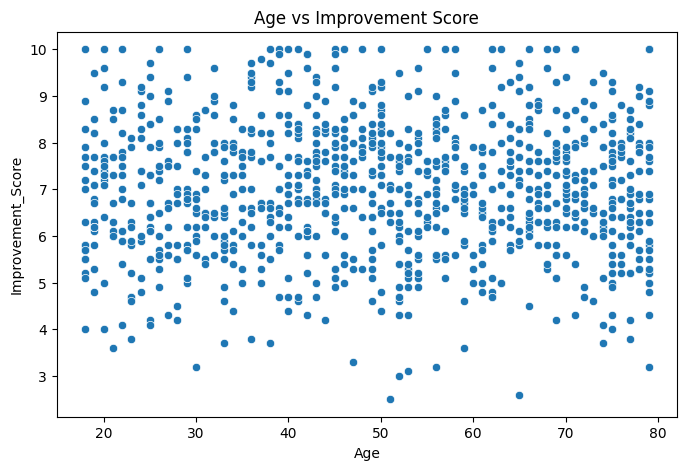

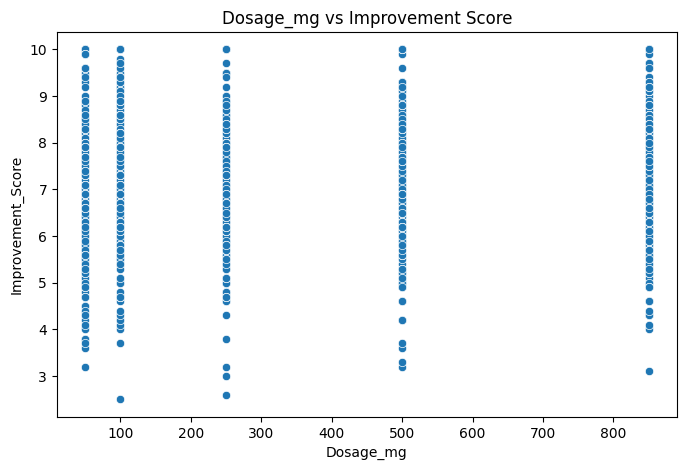

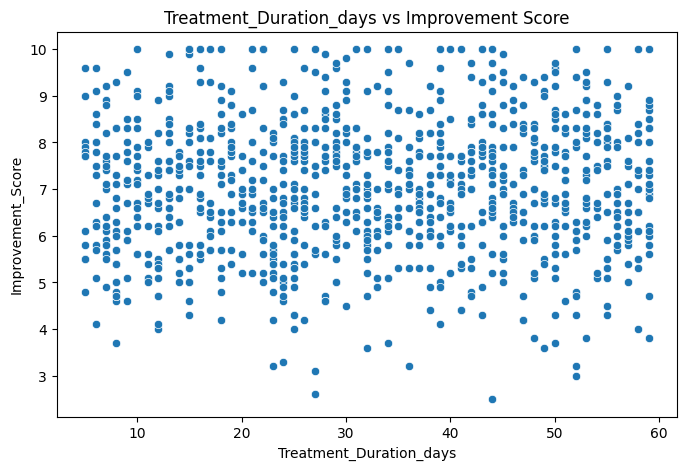

In [88]:
# Numerical variables vs Improvement Score
numerical_cols = ['Age', 'Dosage_mg', 'Treatment_Duration_days']

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=col, y='Improvement_Score', data=df)
    plt.title(f"{col} vs Improvement Score")
    plt.show()

### Numerical vs Target
- Scatter plots help identify trends or patterns between numerical features and the outcome.

**Observations:**
- **Age:** No discernible trend; effectiveness varies widely across all ages.
- **Dosage:** Higher dosage does not automatically imply better improvement; outcomes vary at all dosage levels.
- **Duration:** No clear linear relationship between treatment duration and improvement score.
- **Insight:** Numerical features alone are weak linear predictors but may have non-linear interactions.

---


### Bivariate analysis and Feature selection Summary

The analysis reveals that the categorical features, **`Condition`** and **`Drug_Name`**, have the strongest relationship with the `Improvement_Score`. In contrast, the numerical features (`Age`, `Dosage_mg`, `Treatment_Duration_days`) and `Gender` show very weak or no direct linear correlation with the outcome.

This suggests that for building a predictive model, tree-based algorithms (like Random Forest or Gradient Boosting) that can effectively handle categorical data and capture non-linear interactions will likely outperform simple linear models.

---
